<a href="https://colab.research.google.com/github/reitezuz/18NES1-2026/blob/main/week04/perceptron_layer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Motivation: A Layer of perceptrons
- the whole layer is represented by a weight matrix W and a bias vector b
- the training set also consists of two matrices: X (inputs) and D (true outputs)

In [164]:
import numpy as np
N = 4 # number of samples
n = 2 # number of features
m = 5 # number of neurons

# Layer of perceptrons:
W = np.random.uniform(-1,1,(n,m)) # weight matrix (n,m)
b = np.random.uniform(-1,1,(1,m)) # bias vector (1,m)

# Training set:
X = np.random.uniform(-1,1,(N,n)) # input matrix (N,n)
D = np.random.uniform(-1,1,(N,m)) # desired output matrix (N,m)

print("W:", W, sep="\n")
print("b:", b, sep="\n")
print("X:", X, sep="\n")
print("D:", D, sep="\n")


W:
[[-0.84718858  0.44417642 -0.40794213  0.88869785 -0.07750697]
 [-0.38283143  0.39767203  0.75208439  0.60021104  0.58321893]]
b:
[[ 0.09330941  0.68456092 -0.27042228 -0.68051333 -0.41432769]]
X:
[[ 0.70214342  0.20717944]
 [-0.37772953 -0.98754192]
 [ 0.76202414  0.33970529]
 [ 0.98156685  0.62594039]]
D:
[[ 0.6467347  -0.33252473 -0.54042063  0.76998164 -0.67960194]
 [-0.03328192 -0.89282561 -0.37974885  0.89145319 -0.19897994]
 [-0.93159318 -0.15106326  0.29594251 -0.58262608 -0.21338678]
 [-0.14583199 -0.77145454 -0.85165442  0.35857011  0.73287217]]


- compute the output for a single input pattern

In [165]:
i = 0                     # index of a pattern
x =  X[i,:].reshape(1,-1) # input pattern (1,n)

# Internal potential:
xi = x @ W + b            # (1,n) @ (n,m) => (1, m)

# Output (for tanh and sigmoid):
y = np.tanh(xi)            # (1, m) ... tanh
y1 = 1 / (1 + np.exp(-xi)) # (1, m) ... sigmoid

print("xi:", xi, sep="\n")
print("y (tanh):", y, sep="\n")
print("y1 (sigmoid):", y1, sep="\n")

xi:
[[-0.58085328  1.07882594 -0.40103974  0.06783141 -0.34791772]]
y (tanh):
[[-0.52328533  0.79276331 -0.38083825  0.06772757 -0.33452758]]
y1 (sigmoid):
[[0.35873628 0.74627174 0.40106256 0.51695135 0.41388746]]


- the model is able to compute the potential and output for the whole dataset at once:

In [166]:
# Internal Potential:
Xi = X @ W + b             # (N,n) @ (n,m) => (N, m)

# Output (for tanh and sigmoid):
Y = np.tanh(Xi)            # (N, m) ... tanh
Y1 = 1 / (1 + np.exp(-Xi)) # (N, m) ... sigmoid

# At once:
Y = np.tanh(X @ W + b)     # (N, m)
Y1 = 1 / (1 + np.exp(-(X @ W + b))) # (N, m)

print("Xi:", Xi, sep="\n")
print("Y (tanh):", Y, sep="\n")
print("Y1 (sigmoid):", Y1, sep="\n")


Xi:
[[-0.58085328  1.07882594 -0.40103974  0.06783141 -0.34791772]
 [ 0.79137964  0.12406457 -0.85904536 -1.60893431 -0.96100416]
 [-0.6823186   1.15812536 -0.32579699  0.20059076 -0.27526731]
 [-0.97789247  1.36946875 -0.20008476  0.56749935 -0.12534567]]
Y (tanh):
[[-0.52328533  0.79276331 -0.38083825  0.06772757 -0.33452758]
 [ 0.65918989  0.12343193 -0.69576549 -0.92300239 -0.74472444]
 [-0.59302466  0.82042801 -0.31473914  0.197943   -0.26851924]
 [-0.75215212  0.87857106 -0.19745677  0.51352042 -0.12469332]]
Y1 (sigmoid):
[[0.35873628 0.74627174 0.40106256 0.51695135 0.41388746]
 [0.68812749 0.53097642 0.29753884 0.16673662 0.27667719]
 [0.33574401 0.76099192 0.41926363 0.54998021 0.43161444]
 [0.27331016 0.79729431 0.45014502 0.63818596 0.46870455]]


- one step of the iterative algorithm:

In [167]:
i = 0                     # index of current pattern
x =  X[i,:].reshape(1,-1) # input pattern (1,n)
d = D[i,:].reshape(1,-1)  # real output (1,m)

# Compute the predicted output (for all perceptrons at once)
y = np.tanh(x @ W + b)    #  (1,n) @ (n, m) -> (1, m)

# Compute the weight and bias changes  (for all perceptrons at once)
tanh_derivative = 1 - y ** 2                   # (1,m)
sigmoid_derivative = y * (1 - y)               # (1,m)
W_change = x.T @ (tanh_derivative * (d - y))   # (n,1) @ (1,m) -> (n,m)
b_change = tanh_derivative * (d - y)           # (1,m) * (1,m) -> (1,m)

# Change the weights and biases:
W += W_change
b += b_change

print(f"x: {x.shape}\n{x}")
print(f"d: {d.shape}\n{d}")
print(f"y: {y.shape}\n{y}")
print(f"W_change: {W_change.shape}\n{W_change}")
print(f"b_change: {b_change.shape}\n{b_change}")


x: (1, 2)
[[0.70214342 0.20717944]]
d: (1, 5)
[[ 0.6467347  -0.33252473 -0.54042063  0.76998164 -0.67960194]]
y: (1, 5)
[[-0.52328533  0.79276331 -0.38083825  0.06772757 -0.33452758]]
W_change: (2, 5)
[[ 0.59656655 -0.29354801 -0.09579827  0.49082129 -0.21517714]
 [ 0.17602718 -0.08661637 -0.02826692  0.14482523 -0.0634917 ]]
b_change: (1, 5)
[[ 0.84963632 -0.41807414 -0.1364369   0.69903281 -0.30645753]]


- one step of the batch algorithm (even more efficient):

In [168]:
# Compute the predicted output (for all perceptrons and input patterns at once)
Y = np.tanh(X @ W + b)    #  (N,m)

# Compute the weight and bias changes  (for all perceptrons and input patterns at once)
tanh_derivative = 1 - Y ** 2                   # (N,m)
sigmoid_derivative = Y * (1 - Y)               # (N,m)
W_change = X.T @ (tanh_derivative * (D - Y))   # (n,N) @ (N,m) -> (n,m)
b_change = (tanh_derivative * (D - Y)).sum(axis=0).reshape(1, -1)  # (N,m) * (N,m) ->[sum by rows]-> (1,m)

# Change the weights and biases:
W += W_change
b += b_change

print(f"x: {x.shape}\n{x}")
print(f"d: {d.shape}\n{d}")
print(f"y: {y.shape}\n{y}")
print(f"W_change: {W_change.shape}\n{W_change}")
print(f"b_change: {b_change.shape}\n{b_change}")

x: (1, 2)
[[0.70214342 0.20717944]]
d: (1, 5)
[[ 0.6467347  -0.33252473 -0.54042063  0.76998164 -0.67960194]]
y: (1, 5)
[[-0.52328533  0.79276331 -0.38083825  0.06772757 -0.33452758]]
W_change: (2, 5)
[[-1.12386323 -1.41130413  0.04683539 -0.52754987  0.95388745]
 [-0.3894566  -0.09278304 -0.18025981 -0.65113718  0.414639  ]]
b_change: (1, 5)
[[-1.70755802 -2.81228318  0.40857057  0.06575067  1.31943954]]


# Perceptron Layer with continuous activation function and the gradient descent training algorithm (minimizing the SSE error function)

In [169]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import time

class PerceptronLayer:
    def __init__(self, input_dim, num_neurons, activation_function='linear', init_method='zero'):
        # Dimensions:
        # inputs: (number of samples, number of features) (N, n)
        # weights: (number of features, number of neurons) (n, m)
        # biases: (1, number of neurons) (1, m)

        # weight initialization
        if init_method == 'random':
            self.weights = np.random.uniform(-1, 1, (input_dim, num_neurons)) / 10  # (number of features, number of neurons)
            self.biases = np.random.uniform(-1, 1, (1, num_neurons)) / 10  # (1, number of neurons)
        elif init_method == 'widrow-hoff':
            self.weights = np.random.randn(input_dim, num_neurons) * (2 / np.sqrt(input_dim))  # (number of features, number of neurons)
            self.biases = np.random.randn(1, num_neurons) * (2 / np.sqrt(input_dim))  # (1, number of neurons)
        else: # zeros
            self.weights = np.zeros((input_dim, num_neurons))  # (number of features, number of neurons)
            self.biases = np.zeros((1, num_neurons))  # (1, number of neurons)

        self.activation_function = activation_function
        self.epochs = -1

    def set_weights(self, weights, biases):
        self.weights = np.array(weights, dtype=float).reshape(self.weights.shape)  # (number of features, number of neurons)
        self.biases = np.array(biases, dtype=float).reshape(1, -1)  # (1, number of neurons)

    def __str__(self):
        return f"PerceptronLayer(weights={self.weights.shape}, biases={self.biases.shape})"

    def activation(self, x):
        if self.activation_function == 'linear':
            return x
        elif self.activation_function == 'tanh':
            return np.tanh(x)
        elif self.activation_function == 'sigmoid':
            return 1 / (1 + np.exp(-x))
        else:
            raise ValueError("Unknown activation function")

    def forward(self, inputs):
        # Dimensions:
        # inputs: (number of samples, number of features)
        # weights: (number of features, number of neurons)
        # biases: (1, number of neurons)
        # output: (number of samples, number of neurons)
        potential = inputs @ self.weights + self.biases  # (number of samples, number of neurons)
        return self.activation(potential)  # (number of samples, number of neurons)

    def gradient_descent_iterative(self, training_inputs, true_outputs, learning_rate=1, epochs=100, adaptive_learning_rate=True, min_error=0, max_validation_steps=None, validation_set=None, print_progress=False, error_name='SSE'):
        learning_rate_0 = learning_rate
        training_errors = []
        validation_errors = []

        if print_progress:
            print("Gradient Descent Iterative:")

        if validation_set is not None:
            validation_inputs, validation_true_outputs = validation_set
            validation_steps = 0
            previous_validation_error = MSE_error(validation_true_outputs, self.forward(validation_inputs))

        for epoch in range(epochs):
            shuffled_indices = np.random.permutation(training_inputs.shape[0])
            training_inputs = training_inputs[shuffled_indices, :]
            true_outputs = true_outputs[shuffled_indices, :]


            for inputs, true_output in zip(training_inputs, true_outputs):
                inputs = inputs.reshape(1, -1)  # (1, number of features)
                true_output = true_output.reshape(1, -1)  # (1, number of neurons)
                prediction = self.forward(inputs)  # (1, number of neurons)
                error = true_output - prediction  # (1, number of neurons)

                if (self.activation_function == 'linear') or (error_name != 'SSE'):  # cross-entropy
                    grad = error  # (1, number of neurons)
                elif self.activation_function == 'tanh':
                    grad = error * (1 - prediction ** 2)  # (1, number of neurons)
                elif self.activation_function == 'sigmoid':
                    grad = error * prediction * (1 - prediction)  # (1, number of neurons)
                else:
                    raise ValueError("Unknown activation function")
                self.weights += learning_rate * inputs.T @ grad  # (number of features, number of neurons)
                self.biases += learning_rate * grad  # (1, number of neurons)

            if adaptive_learning_rate:
                learning_rate = learning_rate_0 / ((epoch//100 + 1) ** 0.5)

            if validation_set:
                validation_mse = MSE_error(validation_true_outputs, self.forward(validation_inputs))
                validation_ce = cross_entropy(validation_true_outputs, self.forward(validation_inputs))
                validation_errors.append(validation_mse)
                if validation_mse < previous_validation_error:
                    validation_steps = 0
                else:
                    validation_steps += 1
                previous_validation_error = validation_mse
            mse = MSE_error(true_outputs, self.forward(training_inputs))
            cross_entropy_error = cross_entropy(true_outputs, self.forward(training_inputs))
            if print_progress and epoch % 100 == 0:
                if validation_set:
                    print(f"Epoch: {epoch}, Training MSE: {mse:0.4f}, CE: {cross_entropy_error:.4f} Validation MSE: {validation_mse:0.4f} Validation CE: {validation_ce} Average of Weights: {np.mean(self.weights)}  Learning rate: {learning_rate:.4f}")
                else:
                    print(f"Epoch: {epoch}, MSE: {mse:0.4f} CE: {cross_entropy_error:.4f}  Average of Weights: {np.mean(self.weights)}  Learning rate: {learning_rate:.4f}")

            # Stop conditions:

            training_errors.append(mse)
            if (mse <= min_error):
                msg = "Minimum error reached."
                break
            elif (max_validation_steps and (validation_steps > max_validation_steps)):
                msg = "Maximum validation steps reached."
                break
            else:
                msg = "Maximum epochs reached."
        if print_progress:
            print(f"The training ended after {epoch+1} epochs.", msg)

        self.epochs = epoch + 1
        return training_errors, validation_errors

    def gradient_descent_batch(self, training_inputs, true_outputs, learning_rate=1, epochs=100, adaptive_learning_rate=True, min_error=0, max_validation_steps=None, validation_set=None, print_progress=False, error_name='SSE'):
        learning_rate_0 = learning_rate
        training_errors = []
        validation_errors = []

        if print_progress:
            print("Gradient Descent Batch:")

        if validation_set is not None:
            validation_inputs, validation_true_outputs = validation_set
            validation_steps = 0
            previous_validation_error = MSE_error(validation_true_outputs, self.forward(validation_inputs))

        for epoch in range(epochs):
            prediction = self.forward(training_inputs)  # (number of samples, number of neurons)
            error = true_outputs - prediction  # (number of samples, number of neurons)


            if (self.activation_function == 'linear') or (error_name != 'SSE'):  # cross-entropy
                grad = error  # (number of samples, number of neurons)
            elif self.activation_function == 'tanh':
                grad = error * (1 - prediction ** 2)  # (number of samples, number of neurons)
            elif self.activation_function == 'sigmoid':
                grad = error * prediction * (1 - prediction)  # (number of samples, number of neurons)
            else:
                raise ValueError("Unknown activation function")

            weight_gradient = (training_inputs.T @ grad) / training_inputs.shape[0]  # (number of features, number of neurons)
            bias_gradient = np.mean(grad, axis=0, keepdims=True)  # (1, number of neurons)

            self.weights += learning_rate * weight_gradient  # (number of features, number of neurons)
            self.biases += learning_rate * bias_gradient  # (1, number of neurons)

            if adaptive_learning_rate:
                learning_rate = learning_rate_0 / ((epoch + 1) ** 0.5)

            if validation_set:
                validation_mse = MSE_error(validation_true_outputs, self.forward(validation_inputs))
                validation_ce = cross_entropy(validation_true_outputs, self.forward(validation_inputs))
                validation_errors.append(validation_mse)
                if validation_mse < previous_validation_error:
                    validation_steps = 0
                else:
                    validation_steps += 1
                previous_validation_error = validation_mse

            mse = MSE_error(true_outputs, self.forward(training_inputs))
            cross_entropy_error = cross_entropy(true_outputs, self.forward(training_inputs))
            training_errors.append(mse)
            if print_progress and epoch % 100 == 0:
                if validation_set:
                    print(f"Epoch: {epoch}, Training MSE: {mse:0.4f}, CE: {cross_entropy_error:.4f} Validation MSE: {validation_mse:0.4f} Validation CE: {validation_ce} Average of Weights: {np.mean(self.weights)}  Learning rate: {learning_rate:.4f}")
                else:
                    print(f"Epoch: {epoch}, MSE: {mse:0.4f} CE: {cross_entropy_error:.4f}  Average of Weights: {np.mean(self.weights)}  Learning rate: {learning_rate:.4f}")

            # Stop conditions:
            if (mse <= min_error):
                msg = "Minimum error reached."
                break
            elif (max_validation_steps and validation_steps > max_validation_steps):
                msg = "Maximum validation steps reached."
                break
            else:
                msg = "Maximum epochs reached."
        if print_progress:
            print(f"The training ended after {epoch+1} epochs.", msg)

        self.epochs = epoch + 1
        return training_errors, validation_errors


def sign(x):
    return np.where(x > 0, 1, np.where(x < 0, -1, 0))

def ensure_same_dimensions(true_outputs, predicted_outputs):
    true_outputs = np.asarray(true_outputs)           # ensure array
    predicted_outputs = np.asarray(predicted_outputs)
    true_outputs = true_outputs.reshape(1, -1) if true_outputs.ndim == 1 else true_outputs
    predicted_outputs = predicted_outputs.reshape(1, -1) if predicted_outputs.ndim == 1 else predicted_outputs

    if true_outputs.shape != predicted_outputs.shape:
        raise ValueError(f"Shape mismatch: {true_outputs.shape} vs {predicted_outputs.shape}")
    return true_outputs, predicted_outputs

def perceptron_error(true_outputs, predicted_outputs):
    true_outputs, predicted_outputs = ensure_same_dimensions(true_outputs, predicted_outputs)
    return np.sum(true_outputs != np.round(predicted_outputs))

def SSE_error(true_outputs, predicted_outputs):
    true_outputs, predicted_outputs = ensure_same_dimensions(true_outputs, predicted_outputs)
    return np.sum((true_outputs - predicted_outputs) ** 2)

def SAE_error(true_outputs, predicted_outputs):
    rue_outputs, predicted_outputs = ensure_same_dimensions(true_outputs, predicted_outputs)
    return np.sum(np.abs(true_outputs - predicted_outputs))

def MAE_error(true_outputs, predicted_outputs):
    true_outputs, predicted_outputs = ensure_same_dimensions(true_outputs, predicted_outputs)
    return np.mean(np.abs(true_outputs - predicted_outputs))

def MSE_error(true_outputs, predicted_outputs):
    true_outputs, predicted_outputs = ensure_same_dimensions(true_outputs, predicted_outputs)
    return np.mean((true_outputs - predicted_outputs) ** 2)

def RMSE_error(true_outputs, predicted_outputs):
    true_outputs, predicted_outputs = ensure_same_dimensions(true_outputs, predicted_outputs)
    return np.sqrt(np.mean((true_outputs - predicted_outputs) ** 2))

import numpy as np

def accuracy(true_outputs, predicted_outputs):
    """
    Computes accuracy for classification with real-valued outputs (and for bipolar true outputs).

    Parameters:
    - true_outputs: ndarray of shape (N, m), one-hot encoded true labels (for multi-class)
    - predicted_outputs: ndarray of shape (N, m), real-valued predictions (probabilities or scores)

    Returns:
    - Scalar: Accuracy (proportion of correctly classified samples)
    """
    true_outputs, predicted_outputs = ensure_same_dimensions(true_outputs, predicted_outputs)

    if true_outputs.shape[1] == 1:  # Binary classification (1 neuron)
        predicted_labels = (predicted_outputs >= 0.0).astype(int) *2 - 1 # Convert probabilities to -1/1 using thresholding
    else:  # Multi-class classification (m > 1)
        predicted_labels = np.argmax(predicted_outputs, axis=1)  # Get index of the highest probability
        true_outputs = np.argmax(true_outputs, axis=1)  # Convert one-hot encoding to class indices

    return np.mean(predicted_labels == true_outputs)  # Compute the proportion of correctly classified samples

def misclassified_indices(true_outputs, predicted_outputs):
    """
    Identifies indices of misclassified samples in classification with real-valued outputs.

    Parameters:
    - true_outputs: ndarray of shape (N, m), one-hot encoded true labels (for multi-class)
    - predicted_outputs: ndarray of shape (N, m), real-valued predictions (probabilities or scores)

    Returns:
    - misclassified_indices: ndarray of shape (K,), indices of misclassified samples
    """
    true_outputs, predicted_outputs = ensure_same_dimensions(true_outputs, predicted_outputs)

    if true_outputs.shape[1] == 1:  # Binary classification (1 neuron)
        predicted_labels = (predicted_outputs >= 0.0).astype(int) *2 - 1 # Convert to -1/1
    else:  # Multi-class classification (m > 1)
        predicted_labels = np.argmax(predicted_outputs, axis=1)  # Get predicted class index
        true_outputs = np.argmax(true_outputs, axis=1)  # Convert one-hot encoding to class indices

    misclassified = np.where(predicted_labels != true_outputs)[0]  # Get indices of incorrect predictions

    return misclassified

def cross_entropy(true_outputs, predicted_probabilities, epsilon=1e-12):
    """
    Computes categorical cross-entropy loss for one-hot encoded labels.

    Parameters:
    - true_outputs: ndarray of shape (N, m), one-hot encoded true labels.
    - predicted_probabilities: ndarray of shape (N, m), predicted probabilities.
    - epsilon: Small value to prevent log(0) issues.

    Returns:
    - Mean cross-entropy loss (scalar)
    """
    true_outputs, predicted_outputs = ensure_same_dimensions(true_outputs, predicted_probabilities)

    # Check if we need to apply activation functions
    if predicted_outputs.shape[1] == 1:  # Binary classification: apply sigmoid
        predicted_outputs = 1 / (1 + np.exp(-predicted_outputs))  # Sigmoid function
    else:  # Multi-class classification: apply softmax
        exp_outputs = np.exp(predicted_outputs - np.max(predicted_outputs, axis=1, keepdims=True))  # Stability trick
        predicted_outputs = exp_outputs / np.sum(exp_outputs, axis=1, keepdims=True)


    # Avoid log(0)
    predicted_outputs = np.clip(predicted_outputs, epsilon, 1.0 - epsilon)

    # Cross-entropy loss (averaged over patterns)
    return -np.mean(np.sum(true_outputs * np.log(predicted_outputs), axis=1))


In [170]:
# test of dimensions
p = PerceptronLayer(n,m,activation_function='tanh',init_method='random')
print(p)
X = np.random.uniform(-1,1,(N,n))
D = np.random.uniform(-1,1,(N,m))
Y = p.forward(X)
print(Y, Y.shape, sep="\n")

x = np.random.uniform(-1,1,(1,n))
d = np.random.uniform(-1,1,(1,m))
y = p.forward(x)
print(y, y.shape, sep="\n")

PerceptronLayer(weights=(2, 5), biases=(1, 5))
[[-9.05277563e-02  5.24235702e-05 -1.00161568e-01  6.81838000e-02
  -8.86040414e-02]
 [-6.20241544e-02  4.92218796e-02 -7.39061986e-02  7.24343235e-02
  -1.07983522e-01]
 [-5.94121860e-02  4.33417614e-02 -7.78876848e-02  5.89754990e-02
  -9.83771618e-02]
 [ 3.24313252e-02  1.20518790e-01 -4.26641395e-02 -3.43505210e-02
  -7.27543913e-02]]
(4, 5)
[[-0.00747955  0.06066097 -0.07435599 -0.02940233 -0.05459429]]
(1, 5)


### Axiliary functions:


In [171]:
def run_example_multiple_times_classification(experiment_results, training_data, testing_data, testing_data2, validation_data, activation, epochs, init_method, learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, error_name, max_validation_steps=10, num_runs=10):
    inputs, true_outputs = training_data
    if testing_data is None:
        testing_data = training_data
    if testing_data2 is None:
        testing_dat2 = testing_data
    max_validation_steps = None if validation_data is None else max_validation_steps
    test_inputs, test_true_outputs = testing_data
    test_inputs2, test_true_outputs2 = testing_data2
    times = []
    mse_errors = []
    accuracy_errors = []
    mse_test_errors = []
    accuracy_test_errors = []
    mse_test_errors2 = []
    accuracy_test_errors2 = []
    epoch_counts = []

    for _ in range(num_runs):

        start_time = time.time()
        neuron = PerceptronLayer(inputs.shape[1], true_outputs.shape[1], activation, init_method)

        if variant == 'iterative':
            [training_errors, validation_errors] = neuron.gradient_descent_iterative(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress, error_name)
        else:
            [training_errors, validation_errors] =     neuron.gradient_descent_batch(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress, error_name)

        end_time = time.time()
        elapsed_time = end_time - start_time

        real_outputs = neuron.forward(inputs)
        mse = MSE_error(true_outputs, real_outputs)
        acc = accuracy(true_outputs, real_outputs)

        real_outputs = neuron.forward(test_inputs)
        mse_test = MSE_error(test_true_outputs, real_outputs)
        acc_test = accuracy(test_true_outputs, real_outputs)

        recalled_outputs = neuron.forward(test_inputs2)
        mse_test2 = MSE_error(test_true_outputs2, real_outputs)
        acc_test2 = accuracy(test_true_outputs2, real_outputs)

        times.append(elapsed_time)
        mse_errors.append(mse)
        accuracy_errors.append(acc)
        mse_test_errors.append(mse_test)
        accuracy_test_errors.append(acc_test)
        mse_test_errors2.append(mse_test2)
        accuracy_test_errors2.append(acc_test2)
        epoch_counts.append(neuron.epochs)

    avg_time = np.mean(times)
    avg_mse = np.mean(mse_errors)
    avg_mse_test = np.mean(mse_test_errors)
    avg_acc = np.mean(accuracy_errors)
    acc_sum = np.sum(np.array(accuracy_errors) > 0.98)
    avg_acc_test = np.mean(accuracy_test_errors)
    avg_mse_test2 = np.mean(mse_test_errors2)
    avg_acc_test2 = np.mean(accuracy_test_errors2)
    avg_epochs = np.mean(epoch_counts)

    results = {
        'Epochs': avg_epochs,
        'MSE': avg_mse,
        'Accuracy': avg_acc,
        'Test MSE': avg_mse_test,
        'Test Accuracy': avg_acc_test,
        'Sum Accuracy': acc_sum,
        'Test MSE2': avg_mse_test2,
        'Test Accuracy2': avg_acc_test2,
        'Time': avg_time,
        'Variant': variant,
        'Learning Rate': learning_rate,
        'Adaptive Learning Rate': adaptive_learning_rate,
        'Activation Function': activation,
        'Init Method': init_method,
        'Max Epochs': epochs,
        'Data Description': data_description,

    } #experiment_results_r = pd.DataFrame(columns=['MSE', 'SSE', 'Test MSE' 'Test MAE', 'Epochs', 'Time', 'Variant', 'Learning Rate', 'Max Epochs', 'Weights', 'Bias', 'Data Description'])

    experiment_results.loc[len(experiment_results)] = results

    if num_runs == 1:
         plot_error_progress(training_errors, validation_errors)
    return neuron

def run_example_multiple_times_regression(experiment_results, training_data, testing_data, validation_data, activation, epochs, init_method, learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, max_validation_steps=10, num_runs=10):
    inputs, true_outputs = training_data
    if testing_data is None:
        testing_data = training_data
    max_validation_steps = None if validation_data is None else max_validation_steps
    test_inputs, test_true_outputs = testing_data
    times = []
    mse_errors = []
    mae_errors = []
    mse_test_errors = []
    mae_test_errors = []
    epoch_counts = []

    for _ in range(num_runs):

        start_time = time.time()
        neuron = PerceptronLayer(inputs.shape[1], true_outputs.shape[1], activation, init_method)

        if variant == 'iterative':
            [training_errors, validation_errors] = neuron.gradient_descent_iterative(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress)
        else:
            [training_errors, validation_errors] = neuron.gradient_descent_batch(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, print_progress, print_progress=print_progress)

        end_time = time.time()
        elapsed_time = end_time - start_time

        real_outputs = neuron.forward(inputs)
        mse = MSE_error(true_outputs, real_outputs)
        mae = MAE_error(true_outputs, real_outputs)

        real_outputs = neuron.forward(test_inputs)
        mse_test = MSE_error(test_true_outputs, real_outputs)
        mae_test = MAE_error(test_true_outputs, real_outputs)

        times.append(elapsed_time)
        mse_errors.append(mse)
        mae_errors.append(mae)
        mse_test_errors.append(mse_test)
        mae_test_errors.append(mae_test)
        epoch_counts.append(neuron.epochs)

    avg_time = np.mean(times)
    avg_mse = np.mean(mse_errors)
    avg_mae = np.mean(mae_errors)
    avg_test_mse = np.mean(mse_test_errors)
    avg_test_mae = np.mean(mae_test_errors)
    avg_epochs = np.mean(epoch_counts)

    results = {
        'Epochs': avg_epochs,
        'MSE': avg_mse,
        'MAE': avg_mae,
        'Test MSE': avg_test_mse,
        'Test MAE': avg_test_mae,
        'Time': avg_time,
        'Variant': variant,
        'Learning Rate': learning_rate,
        'Max Epochs': epochs,
        'Weights': neuron.weights,  # Note: Weights and bias are from the last run.
        'Bias': neuron.bias,
        'Data Description': data_description
    } #experiment_results_r = pd.DataFrame(columns=['MSE', 'SSE', 'Test MSE' 'Test MAE', 'Epochs', 'Time', 'Variant', 'Learning Rate', 'Max Epochs', 'Weights', 'Bias', 'Data Description'])

    experiment_results.loc[len(experiment_results)] = results

    if num_runs == 1:
         plot_error_progress(training_errors, validation_errors)
    return neuron

def plot_error_progress(train_errors, validation_errors):
    fig = plt.figure(figsize=(4, 3))
    if validation_errors:
        plt.plot(validation_errors, label='Validation Error')
    plt.plot(train_errors, label='Train Error')
    plt.xlabel('Epoch')
    plt.ylabel('Error')
    plt.title('Validation and Train Error Progress')
    plt.legend()
    plt.grid(True)
    plt.show()


def one_hot_encode(d, num_classes=None):
    """
    Converts a vector of class labels (N,1) into a one-hot encoded matrix (N, m) using NumPy.

    Parameters:
    - d: ndarray of shape (N, 1) or (N,), containing class indices (0 to m-1)
    - num_classes: int, total number of classes (if None, inferred from max value in d)

    Returns:
    - one_hot: ndarray of shape (N, m), where each row is a one-hot vector
    """
    d = np.asarray(d).reshape(-1)  # Convert (N,1) to (N,) if necessary

    if num_classes is None:
        num_classes = np.max(d) # Infer number of classes if not provided

    return np.eye(num_classes)[d-1] * 2 - 1 # Efficient one-hot encoding




# Example 1: Gallblader attack
- now, we train three tasks at once:
    1. Gallblader attack
    2. Egg Salad
    3. Majority Circuit

In [172]:
def example_gallblader_attack():
    # Egg Salad, Pork Belly, Medicines -> Gallbladder Attack, Egg Salad, Majority
    inputs = np.array([
        [+1, -1, -1],
        [+1, -1, +1],
        [-1, +1, -1],
        [-1, +1, +1],
        [+1, +1, -1],
        [+1, +1, +1]
    ])

    true_outputs = np.array([
        [+1, +1, -1],
        [-1, +1, +1],
        [+1, -1, -1],
        [-1, -1, +1],
        [+1, +1, +1],
        [+1, +1, +1]
    ])
    return inputs, true_outputs

- Observe that the perceptron layer manages to learn three tasks at once
- experiment with the hyperparameters

(6, 3) (6, 3)
Gradient Descent Iterative:
Epoch: 0, MSE: 0.3769 CE: 0.4282  Average of Weights: 0.11379577675194359  Learning rate: 0.1000
The training ended after 50 epochs. Maximum epochs reached.
PerceptronLayer(weights=(3, 3), biases=(1, 3))
Perceptron error: 0
MAE error: 0.0925966346541743
MSE error: 0.011507612326443801


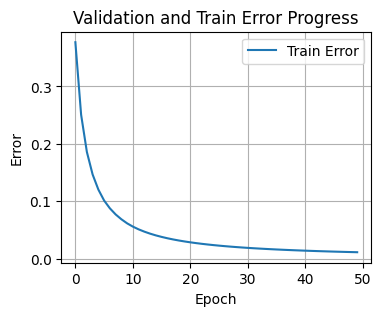

,Input,Predicted,True
0,"[1, -1, -1]","[[0.9168928648568301, 0.9709673450293971, -0.8...","[1, 1, -1]"
1,"[1, -1, 1]","[[-0.8490218863217756, 0.9709666529080242, 0.9...","[-1, 1, 1]"
2,"[-1, 1, -1]","[[0.9166531644925688, -0.9195892105419285, -0....","[1, -1, -1]"
3,"[-1, 1, 1]","[[-0.8494408112170433, -0.9195910774751077, 0....","[-1, -1, 1]"
4,"[1, 1, -1]","[[0.9993256782255975, 0.9195916660563196, 0.82...","[1, 1, 1]"
5,"[1, 1, 1]","[[0.8260282551985005, 0.9195897991362336, 0.99...","[1, 1, 1]"


In [173]:
# Data and parameters:
inputs, true_outputs = example_gallblader_attack()
data_description = "Logical function"
print(inputs.shape, true_outputs.shape)

# set parameters:
print_progress = True
activation = 'tanh'
learning_rate = 0.1 #  0.5
init_method = 'random'
adaptive_learning_rate = False
min_error = 0.0001
epochs = 50
variant = "iterative"
validation_data = None
max_validation_steps = None

# run the experiment:

# Train the linear neuron:
perceptron = PerceptronLayer(inputs.shape[1], true_outputs.shape[1], activation, init_method)


if variant == 'iterative':
    [training_errors, validation_errors] = perceptron.gradient_descent_iterative(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress)
else:
    [training_errors, validation_errors] = perceptron.gradient_descent_batch(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress)


# Print summary:
print(perceptron)
real_outputs = perceptron.forward(inputs) # forward for the whole dataset
error = perceptron_error(true_outputs, real_outputs)
print(f"Perceptron error: {error}")
print(f"MAE error: {MAE_error(true_outputs, real_outputs)}")
print(f"MSE error: {MSE_error(true_outputs, real_outputs)}")
plot_error_progress(training_errors, validation_errors)


# Create a pandas DataFrame for a nice table
import pandas as pd
df = pd.DataFrame(columns=['Input', 'Predicted', 'True'])
for inputs, label in zip(inputs, true_outputs):
    df.loc[len(df)] = {'Input': inputs, 'Predicted': perceptron.forward(inputs), 'True': label}
df.round(2)


In [174]:
perceptron.weights, perceptron.biases


(array([[ 1.21482199e+00,  1.58636702e+00,  1.21313538e+00],
        [ 1.21407070e+00, -2.61277142e-01,  1.21331682e+00],
        [-1.41090187e+00, -6.04757110e-06,  1.40945802e+00]]),
 array([[0.15751199, 0.26127905, 0.15543741]]))

# Example:  Letters
#### Dataset Description:
The dataset consists of 78 black and white images of letters represented as numerical arrays.
Each image is a 50x50 grid where pixel values are either -1 (black) or 1 (white).
- The first column in the dataset contains the class label, which represents the letter index (1-26).
- The remaining columns contain pixel values for the respective image.

In [175]:
# load the perceptron_library.py file into google colab
import urllib.request

url = 'https://raw.githubusercontent.com/reitezuz/18NES1-2025-/refs/heads/main/week2/perceptron_library.py'
filename = 'perceptron_library.py'
urllib.request.urlretrieve(url, filename)


('perceptron_library.py', <http.client.HTTPMessage at 0x79def8b8ec60>)

In [176]:
# import libraries
#from perceptron_library import *
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt


In [177]:
def load_letter_data():
    """ Load letter image data from a CSV file hosted on GitHub into numpy arrays """
    github_url = "https://github.com/reitezuz/18NES1-2025-/blob/cd9bb8168f96cb0c35a6502c0d1b3874113c24ae/week2/letters.csv"
    url = github_url.replace("github.com", "raw.githubusercontent.com").replace("blob/", "")
    df = pd.read_csv(url, header=None)
    labels = df.iloc[:, 0].values   # First column is the class label
    inputs = df.iloc[:, 1:].values  # Remaining columns are features (-1, 1)
    return inputs, labels

def visualize_letter(X, labels, index):
    """ Visualize the i-th row of the data as a 50x50 black and white image """
    image = - X[index].reshape(50, 50)  # Reshape to 50x50
    letter = label_to_letter(labels[index])
    plt.figure(figsize=(2,2))         # Figure size
    plt.imshow(image, cmap='gray', vmin=-1, vmax=1)
    plt.title(f"Letter Image at Index {index} ... {letter}")
    plt.axis('off')
    plt.show()

def label_to_letter(label):
    """ Convert a label (1-26) to a corresponding letter (A-Z) """
    return chr(label + 64)

def add_noise(X, alpha=0.01):
    """ Add salt & pepper noise to the dataset and apply median filtering """
    from scipy.ndimage import median_filter
    X = (X + 1) / 2  # Convert from [-1,1] to [0,1]
    X_noisy = X.copy()
    X_denoised = X.copy()

    for i in range(X.shape[0]):
        img = X[i].reshape(50, 50)

        # Add salt & pepper noise
        noisy_img = img.copy()
        noise = np.random.choice([0, 1, -1], size=img.shape, p=[1 - alpha, alpha / 2, alpha / 2])
        noisy_img[noise == -1] = 0  # Salt (white)
        noisy_img[noise == 1] = 1   # Pepper (black)

        # Apply median filter
        denoised_img = median_filter(noisy_img, size=3)

        # Flatten back to vector form
        X_noisy[i] = noisy_img.flatten()
        X_denoised[i] = denoised_img.flatten()

    X_noisy = X_noisy * 2 - 1  # Convert back to [-1,1]
    X_denoised = X_denoised * 2 - 1  # Convert back to [-1,1]

    return X_noisy, X_denoised

def show_noisy_and_denoised(X_original, X_noisy, X_denoised, index):
    """ Display original, noisy, and denoised images side by side """
    fig, axes = plt.subplots(1, 3, figsize=(10, 5))

    original_img = - X_original[index].reshape(50, 50)
    noisy_img = - X_noisy[index].reshape(50, 50)
    denoised_img = - X_denoised[index].reshape(50, 50)

    axes[0].imshow(original_img, cmap='gray', vmin=-1, vmax=1)
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    axes[1].imshow(noisy_img, cmap='gray', vmin=-1, vmax=1)
    axes[1].set_title("Noisy Image")
    axes[1].axis('off')

    axes[2].imshow(denoised_img, cmap='gray', vmin=-1, vmax=1)
    axes[2].set_title("Denoised Image")
    axes[2].axis('off')

    plt.show()


### Analyze the data:

In [178]:
# Load the data:
[inputs, labels] = load_letter_data()

print(np.shape(inputs), np.shape(labels))
print(np.max(inputs), np.min(inputs), np.max(labels), np.min(labels))



(78, 2500) (78,)
1 -1 26 1


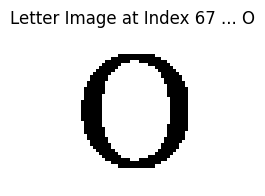

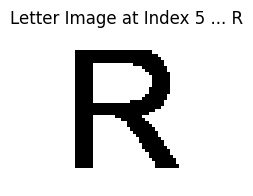

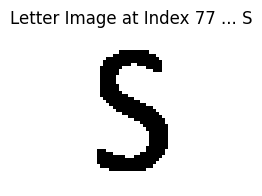

In [179]:
# Visualize some letters:
indexes = [67, 5, 77]
for index in indexes:
    visualize_letter(inputs, labels, index)


Create the testing set by adding noise and denoising:
- experiment with the level of noise, alpha

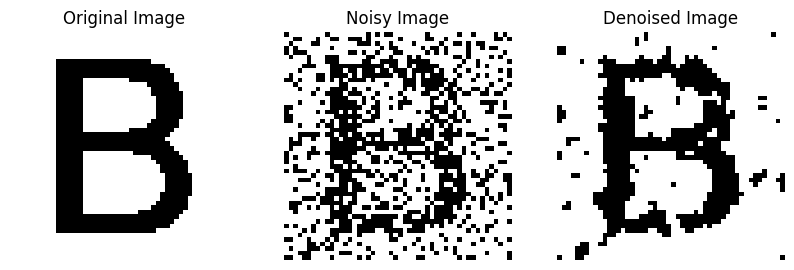

In [180]:
[inputs_noisy, inputs_denoised] = add_noise(inputs, alpha=0.5)
index = 10
show_noisy_and_denoised(inputs, inputs_noisy, inputs_denoised, index)

## Train the Perceptron layer to recognize letters

In [181]:
# DataFrame to store the results for comparisons
experiment_results_let = pd.DataFrame(columns=['Epochs', 'MSE', 'Accuracy','Sum Accuracy', 'Test MSE', 'Test Accuracy', 'Test MSE2', 'Test Accuracy2', 'Time', 'Variant', 'Learning Rate', 'Adaptive Learning Rate', 'Activation Function', 'Init Method', 'Max Epochs', 'Data Description'])

### 5 letters

- at first we train a small number of letters
- set the parametrers, run the experiment and observe the results:
- observe the characteristic shape of the error progress (for SSE)

Gradient Descent Iterative:
Epoch: 0, MSE: 1.3535 CE: -6.6758  Average of Weights: 9.301338135714195e-05  Learning rate: 0.0010
Epoch: 100, MSE: 0.3722 CE: -7.1573  Average of Weights: 0.0012553884037067493  Learning rate: 0.0010
Epoch: 200, MSE: 0.1603 CE: -8.3262  Average of Weights: 0.0011465067228065933  Learning rate: 0.0010
Epoch: 300, MSE: 0.1602 CE: -8.3441  Average of Weights: 0.0011777566434101397  Learning rate: 0.0010
Epoch: 400, MSE: 0.1601 CE: -8.3527  Average of Weights: 0.001194247104984528  Learning rate: 0.0010
Epoch: 500, MSE: 0.1601 CE: -8.3582  Average of Weights: 0.0012045413327476506  Learning rate: 0.0010
Epoch: 600, MSE: 0.1601 CE: -8.3621  Average of Weights: 0.0012105474958713513  Learning rate: 0.0010
Epoch: 700, MSE: 0.1601 CE: -8.3650  Average of Weights: 0.0012125735792402187  Learning rate: 0.0010
Epoch: 800, MSE: 0.1600 CE: -8.3673  Average of Weights: 0.001208537351272446  Learning rate: 0.0010
Epoch: 900, MSE: 0.1599 CE: -8.3687  Average of Weights: 0

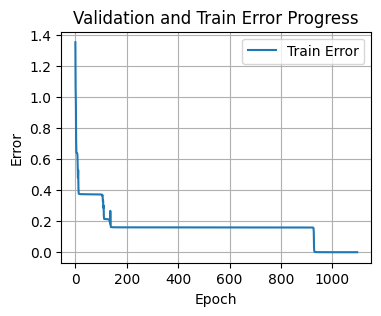


Experiment Results:


,Epochs,MSE,Accuracy,Sum Accuracy,Test MSE,Test Accuracy,Test MSE2,Test Accuracy2,Time,Variant,Learning Rate,Adaptive Learning Rate,Activation Function,Init Method,Max Epochs,Data Description
0,1098.0,0.0001,1.0,1,0.431522,0.733333,0.431522,0.733333,1.542547,iterative,0.001,False,tanh,random,5000,Letter classification


In [182]:
alpha = 0.3       # level of noise in the testing data

np.random.seed(47876)
# Preprocess the data:
[inputs, labels] = load_letter_data()

mask = (labels == 1) | (labels == 2) | (labels == 3) | (labels == 4)| (labels == 5)  # we train just 5  letters
inputs = inputs[mask]
labels = labels[mask]

[inputs_noisy, inputs_denoised] = add_noise(inputs, alpha=alpha)
true_outputs = one_hot_encode(labels)
training_data = (inputs, true_outputs)


testing_data = (inputs_noisy, true_outputs)
validation_data = None
testing_data2 = (inputs_denoised, true_outputs)
data_description = "Letter classification"

# Set Perceptron parameters:
weights = np.zeros(inputs.shape[1])
bias = 0
activation = 'tanh'
init_method = 'random'
epochs = 5000
learning_rate = 0.001
adaptive_learning_rate = False
min_error = 0.0001
print_progress = True
variant ='iterative' # 'batch' # 'batch' 'iterative'
max_validation_steps = 30
error_name = 'SSE'# 'cross-entropy'

# run the experiment:
#for learning_rate in [0.0001, 0.001, 0.01, 0.1, 1]:

perceptron = run_example_multiple_times_classification(experiment_results_let, training_data, testing_data, testing_data2, validation_data, activation, epochs, init_method, learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, error_name, max_validation_steps, num_runs=1)

#perceptron = run_example_multiple_times_classification(experiment_results_let, training_data, testing_data, testing_data2, validation_data, activation, epochs, init_method, learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, max_validation_steps, num_runs=1)

print("\nExperiment Results:")
experiment_results_let

- visualize misclassified letters:

Misclassified Letters:


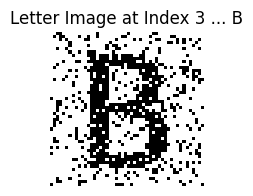

  Predicted: D, Actual: B
  Output: [-0.92 -0.99 -1.   -0.35 -0.99]
  Probabilities: [0.1  0.01 0.   0.86 0.02]


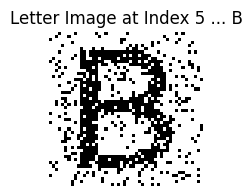

  Predicted: D, Actual: B
  Output: [-1.    0.99 -1.    0.99 -0.88]
  Probabilities: [0.   0.48 0.   0.49 0.03]


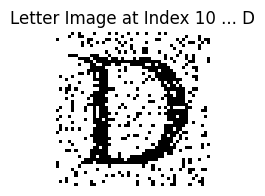

  Predicted: B, Actual: D
  Output: [-0.99  0.49 -1.   -0.82 -0.69]
  Probabilities: [0.01 0.75 0.   0.09 0.16]


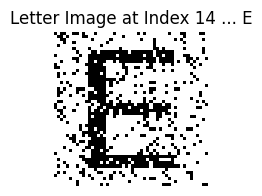

  Predicted: D, Actual: E
  Output: [-1.   -1.   -1.    0.51 -0.82]
  Probabilities: [0.   0.   0.   0.89 0.11]


In [183]:
outputs = perceptron.forward(inputs_noisy)

# Find misclassified letters
misc = misclassified_indices(true_outputs, outputs)
outputs = perceptron.forward(inputs_noisy)

# Visualize misclassified letters
print("Misclassified Letters:")
for index in misc:
    visualize_letter(inputs_noisy, labels, index)
    predicted_class = np.argmax(outputs[index]) + 1  # Get predicted class index (add 1 to adjust for 1-based indexing)
    print(f"  Predicted: {label_to_letter(predicted_class)}, Actual: {label_to_letter(labels[index])}")
    print(f"  Output: {np.round(outputs[index], 2)}")
    print(f"  Probabilities: {np.round((outputs[index]+1)/np.sum(outputs[index]+1),2)}")

- train with cross-entropy

Gradient Descent Iterative:
Epoch: 0, MSE: 1.0934 CE: -6.2874  Average of Weights: 0.00013483862253813562  Learning rate: 0.0001
Epoch: 100, MSE: 0.0017 CE: -9.0866  Average of Weights: 0.0009626092108822314  Learning rate: 0.0001
Epoch: 200, MSE: 0.0004 CE: -9.1907  Average of Weights: 0.0010660309766841343  Learning rate: 0.0001
Epoch: 300, MSE: 0.0002 CE: -9.2257  Average of Weights: 0.0011259566143354005  Learning rate: 0.0001
Epoch: 400, MSE: 0.0001 CE: -9.2434  Average of Weights: 0.0011681698995431285  Learning rate: 0.0001
The training ended after 404 epochs. Minimum error reached.


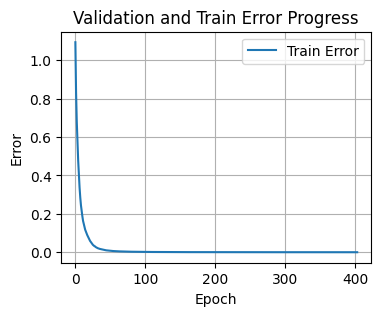


Experiment Results:


,Epochs,MSE,Accuracy,Sum Accuracy,Test MSE,Test Accuracy,Test MSE2,Test Accuracy2,Time,Variant,Learning Rate,Adaptive Learning Rate,Activation Function,Init Method,Max Epochs,Data Description
0,1098.0,0.0001,1.0,1,0.431522,0.733333,0.431522,0.733333,1.542547,iterative,0.0010,False,tanh,random,5000,Letter classification
1,404.0,0.0001,1.0,1,0.401720,0.733333,0.401720,0.733333,0.555499,iterative,0.0001,False,tanh,random,5000,Letter classification


In [184]:
alpha = 0.3      # level of noise in the testing data

np.random.seed(47876)
# Preprocess the data:
[inputs, labels] = load_letter_data()

mask = (labels == 1) | (labels == 2) | (labels == 3) | (labels == 4)| (labels == 5)  # we train just 5  letters
inputs = inputs[mask]
labels = labels[mask]

[inputs_noisy, inputs_denoised] = add_noise(inputs, alpha=alpha)
true_outputs = one_hot_encode(labels)
training_data = (inputs, true_outputs)


testing_data = (inputs_noisy, true_outputs)
validation_data = None
testing_data2 = (inputs_denoised, true_outputs)
data_description = "Letter classification"

# Set Perceptron parameters:
weights = np.zeros(inputs.shape[1])
bias = 0
activation = 'tanh'
init_method = 'random'
epochs = 5000
learning_rate = 0.0001
adaptive_learning_rate = False
min_error = 0.0001
print_progress = True
variant ='iterative' # 'batch' # 'batch' 'iterative'
max_validation_steps = 30
error_name = 'cross-entropy'

# run the experiment:
#for learning_rate in [0.0001, 0.001, 0.01, 0.1, 1]:

perceptron = run_example_multiple_times_classification(experiment_results_let, training_data, testing_data, testing_data2, validation_data, activation, epochs, init_method, learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, error_name, max_validation_steps, num_runs=1)

print("\nExperiment Results:")
experiment_results_let

Misclassified Letters:


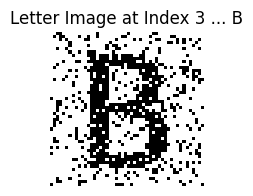

  Predicted: D, Actual: B
  Output: [-0.92 -0.99 -1.   -0.58 -0.96]
  Probabilities: [0.14 0.02 0.   0.77 0.07]


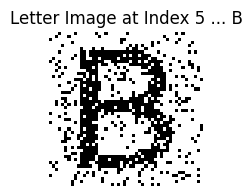

  Predicted: D, Actual: B
  Output: [-1.    0.97 -1.    0.99 -0.81]
  Probabilities: [0.   0.48 0.   0.48 0.04]


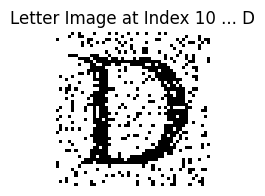

  Predicted: B, Actual: D
  Output: [-0.99  0.47 -1.   -0.69 -0.42]
  Probabilities: [0.   0.62 0.   0.13 0.24]


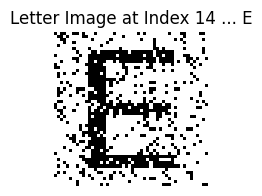

  Predicted: D, Actual: E
  Output: [-1.   -1.   -1.    0.15 -0.85]
  Probabilities: [0.   0.   0.   0.88 0.12]


In [185]:
outputs = perceptron.forward(inputs_noisy)

# Find misclassified letters
misc = misclassified_indices(true_outputs, outputs)
outputs = perceptron.forward(inputs_noisy)

# Visualize misclassified letters
print("Misclassified Letters:")
for index in misc:
    visualize_letter(inputs_noisy, labels, index)
    predicted_class = np.argmax(outputs[index]) + 1  # Get predicted class index (add 1 to adjust for 1-based indexing)
    print(f"  Predicted: {label_to_letter(predicted_class)}, Actual: {label_to_letter(labels[index])}")
    print(f"  Output: {np.round(outputs[index], 2)}")
    print(f"  Probabilities: {np.round((outputs[index]+1)/np.sum(outputs[index]+1),2)}")

### 10 letters
- compare SSE and cross-entropy
- compare the batch and iterative algorithm

Gradient Descent Iterative:
Epoch: 0, MSE: 0.6078 CE: -19.7235  Average of Weights: 0.0010944424619866065  Learning rate: 0.0001
Epoch: 100, MSE: 0.0017 CE: -23.9224  Average of Weights: 0.0015381626625924482  Learning rate: 0.0001
Epoch: 200, MSE: 0.0004 CE: -24.1432  Average of Weights: 0.001664445600426355  Learning rate: 0.0001
Epoch: 300, MSE: 0.0002 CE: -24.2177  Average of Weights: 0.0017393879406983868  Learning rate: 0.0001
Epoch: 400, MSE: 0.0001 CE: -24.2555  Average of Weights: 0.001792846359712485  Learning rate: 0.0001
The training ended after 420 epochs. Minimum error reached.


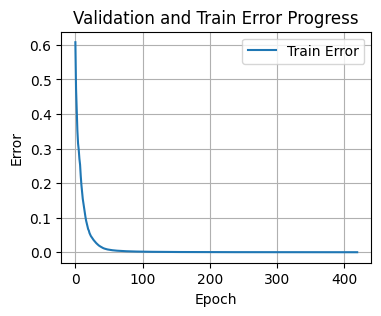


Experiment Results:


,Epochs,MSE,Accuracy,Sum Accuracy,Test MSE,Test Accuracy,Test MSE2,Test Accuracy2,Time,Variant,Learning Rate,Adaptive Learning Rate,Activation Function,Init Method,Max Epochs,Data Description
0,1098.0,0.0001,1.0,1,0.431522,0.733333,0.431522,0.733333,1.542547,iterative,0.0010,False,tanh,random,5000,Letter classification
1,404.0,0.0001,1.0,1,0.401720,0.733333,0.401720,0.733333,0.555499,iterative,0.0001,False,tanh,random,5000,Letter classification
2,420.0,0.0001,1.0,1,0.287859,0.666667,0.287859,0.666667,2.513628,iterative,0.0001,False,tanh,random,10000,Letter classification


In [186]:
alpha = 0.3       # level of noise in the testing data

np.random.seed(47876)
# Preprocess the data:
[inputs, labels] = load_letter_data()

mask = (labels == 1) | (labels == 2) | (labels == 3) | (labels == 4)| (labels == 5) | (labels == 6) | (labels == 7) | (labels == 8) | (labels == 9)| (labels == 10)
inputs = inputs[mask]
labels = labels[mask]

[inputs_noisy, inputs_denoised] = add_noise(inputs, alpha=alpha)
true_outputs = one_hot_encode(labels)
training_data = (inputs, true_outputs)


testing_data = (inputs_noisy, true_outputs)
validation_data = None
testing_data2 = (inputs_denoised, true_outputs)
data_description = "Letter classification"

# Set Perceptron parameters:
weights = np.zeros(inputs.shape[1])
bias = 0
activation = 'tanh'
init_method = 'random'
epochs = 10000
learning_rate = 0.0001
adaptive_learning_rate = False
min_error = 0.0001
print_progress = True
variant = 'iterative' # 'batch' # 'batch' 'iterative'
max_validation_steps = 30
error_name = 'cross-entropy' # 'SSE'# 'cross-entropy'

# run the experiment:
#for learning_rate in [0.0001, 0.001, 0.01, 0.1, 1]:

perceptron = run_example_multiple_times_classification(experiment_results_let, training_data, testing_data, testing_data2, validation_data, activation, epochs, init_method, learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, error_name, max_validation_steps, num_runs=1)

print("\nExperiment Results:")
experiment_results_let

Misclassified Letters:


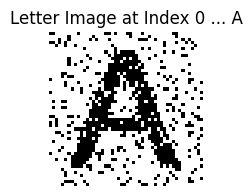

  Predicted: H, Actual: A
  Output: [ 0.9   0.14 -1.   -1.   -1.   -1.   -0.99  0.98 -0.09 -1.  ]
  Probabilities: [0.32 0.19 0.   0.   0.   0.   0.   0.33 0.15 0.  ]


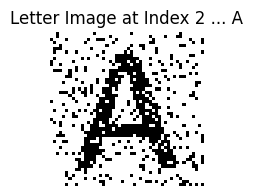

  Predicted: F, Actual: A
  Output: [-0.96 -0.91 -1.   -1.   -1.   -0.37 -1.   -1.   -1.   -1.  ]
  Probabilities: [0.06 0.12 0.   0.   0.   0.81 0.   0.   0.   0.  ]


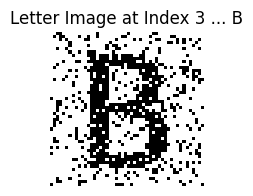

  Predicted: J, Actual: B
  Output: [-1.    0.1  -0.97 -1.   -0.98 -1.   -0.74 -0.97 -1.    0.24]
  Probabilities: [0.   0.41 0.01 0.   0.01 0.   0.1  0.01 0.   0.46]


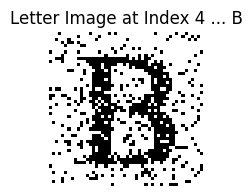

  Predicted: C, Actual: B
  Output: [-1.   -0.97  0.58 -0.99 -1.   -1.   -0.97 -1.   -1.   -0.08]
  Probabilities: [0.   0.01 0.61 0.   0.   0.   0.01 0.   0.   0.36]


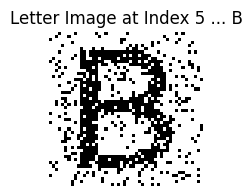

  Predicted: E, Actual: B
  Output: [-1.   -0.99 -1.   -1.   -0.67 -0.91 -0.9  -1.   -1.   -1.  ]
  Probabilities: [0.   0.02 0.   0.   0.62 0.16 0.18 0.   0.   0.01]


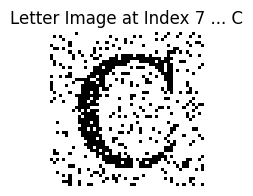

  Predicted: G, Actual: C
  Output: [-1.   -1.   -0.26 -0.99 -0.99 -0.99 -0.11 -1.   -1.   -1.  ]
  Probabilities: [0.   0.   0.45 0.   0.01 0.   0.54 0.   0.   0.  ]


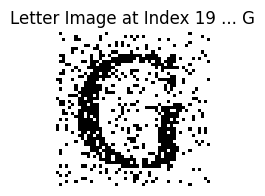

  Predicted: C, Actual: G
  Output: [-1.   -1.    0.9  -0.96 -0.59 -1.    0.83 -1.   -0.84 -1.  ]
  Probabilities: [0.   0.   0.44 0.01 0.09 0.   0.42 0.   0.04 0.  ]


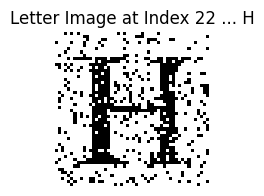

  Predicted: F, Actual: H
  Output: [-1.   -1.   -0.98 -0.92 -1.   -0.89 -1.   -0.97 -0.99 -1.  ]
  Probabilities: [0.01 0.   0.07 0.31 0.   0.47 0.   0.11 0.04 0.  ]


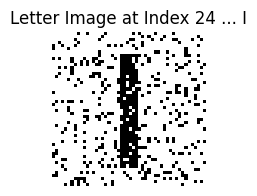

  Predicted: J, Actual: I
  Output: [-0.39 -1.   -1.    0.04 -1.   -0.91 -0.78 -1.   -0.64  0.26]
  Probabilities: [0.17 0.   0.   0.29 0.   0.02 0.06 0.   0.1  0.35]


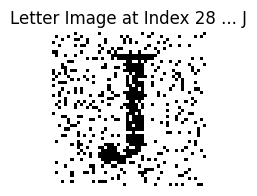

  Predicted: F, Actual: J
  Output: [-0.35 -1.   -0.27 -0.82 -1.    0.99 -1.   -1.   -0.97  0.87]
  Probabilities: [0.12 0.   0.13 0.03 0.   0.37 0.   0.   0.01 0.34]


In [187]:
outputs = perceptron.forward(inputs_noisy)

# Find misclassified letters
misc = misclassified_indices(true_outputs, outputs)
outputs = perceptron.forward(inputs_noisy)

# Visualize misclassified letters
print("Misclassified Letters:")
for index in misc:
    visualize_letter(inputs_noisy, labels, index)
    predicted_class = np.argmax(outputs[index]) + 1  # Get predicted class index (add 1 to adjust for 1-based indexing)
    print(f"  Predicted: {label_to_letter(predicted_class)}, Actual: {label_to_letter(labels[index])}")
    print(f"  Output: {np.round(outputs[index], 2)}")
    print(f"  Probabilities: {np.round((outputs[index]+1)/np.sum(outputs[index]+1),2)}")

In [188]:
Y = perceptron.forward(inputs_noisy)
D = true_outputs

err = np.abs(D - Y)
print(misclassified_indices(true_outputs, Y), accuracy(D, Y))
print( np.sum(D >0.98, axis=0), np.sum(D <-0.98, axis=0))
print( np.sum(Y >0.098, axis=0), np.sum(Y <-0.098, axis=0))

[ 0  2  3  4  5  7 19 22 24 28] 0.6666666666666666
[3 3 3 3 3 3 3 3 3 3] [27 27 27 27 27 27 27 27 27 27]
[2 4 5 4 3 5 2 6 2 5] [27 26 25 24 27 22 28 24 27 23]


### All letters

Gradient Descent Iterative:
Epoch: 0, MSE: 0.2780 CE: -80.2295  Average of Weights: 0.0012363355724272233  Learning rate: 0.0001
Epoch: 100, MSE: 0.0008 CE: -84.8416  Average of Weights: 0.0019799700258672703  Learning rate: 0.0001
Epoch: 200, MSE: 0.0002 CE: -85.1379  Average of Weights: 0.0021458604903375027  Learning rate: 0.0001
The training ended after 296 epochs. Minimum error reached.


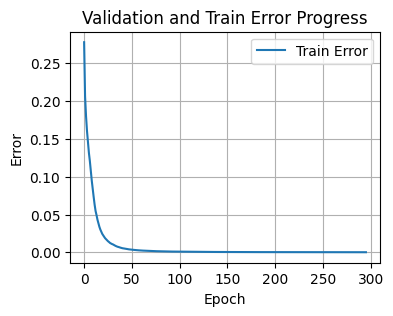


Experiment Results:


,Epochs,MSE,Accuracy,Sum Accuracy,Test MSE,Test Accuracy,Test MSE2,Test Accuracy2,Time,Variant,Learning Rate,Adaptive Learning Rate,Activation Function,Init Method,Max Epochs,Data Description
0,1098.0,0.0001,1.0,1,0.431522,0.733333,0.431522,0.733333,1.542547,iterative,0.0010,False,tanh,random,5000,Letter classification
1,404.0,0.0001,1.0,1,0.401720,0.733333,0.401720,0.733333,0.555499,iterative,0.0001,False,tanh,random,5000,Letter classification
2,420.0,0.0001,1.0,1,0.287859,0.666667,0.287859,0.666667,2.513628,iterative,0.0001,False,tanh,random,10000,Letter classification
3,296.0,0.0001,1.0,1,0.211418,0.487179,0.211418,0.487179,10.841069,iterative,0.0001,False,tanh,random,10000,Letter classification


In [189]:
alpha = 0.3       # level of noise in the testing data

np.random.seed(47876)
# Preprocess the data:
[inputs, labels] = load_letter_data()


[inputs_noisy, inputs_denoised] = add_noise(inputs, alpha=alpha)
true_outputs = one_hot_encode(labels)
training_data = (inputs, true_outputs)


testing_data = (inputs_noisy, true_outputs)
validation_data = None
testing_data2 = (inputs_denoised, true_outputs)
data_description = "Letter classification"

# Set Perceptron parameters:
weights = np.zeros(inputs.shape[1])
bias = 0
activation = 'tanh'
init_method = 'random'
epochs = 10000
learning_rate = 0.0001
adaptive_learning_rate = False
min_error = 0.0001
print_progress = True
variant = 'iterative' # 'batch' # 'batch' 'iterative'
max_validation_steps = 30
error_name = 'cross-entropy' # 'SSE'# 'cross-entropy'

# run the experiment:
#for learning_rate in [0.0001, 0.001, 0.01, 0.1, 1]:

perceptron = run_example_multiple_times_classification(experiment_results_let, training_data, testing_data, testing_data2, validation_data, activation, epochs, init_method, learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, error_name, max_validation_steps, num_runs=1)

print("\nExperiment Results:")
experiment_results_let

Misclassified Letters:


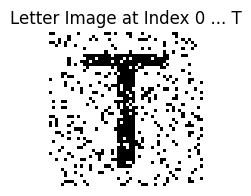

  Predicted: J, Actual: T
  Output: [-1.   -1.   -1.   -1.   -0.99  0.83 -1.   -1.   -1.    0.84 -1.   -1.
 -1.   -0.99 -1.   -1.   -1.   -1.   -0.95 -0.15 -1.   -1.   -1.   -0.86
 -1.   -0.14]
  Probabilities: [0.   0.   0.   0.   0.   0.33 0.   0.   0.   0.33 0.   0.   0.   0.
 0.   0.   0.   0.   0.01 0.15 0.   0.   0.   0.03 0.   0.15]


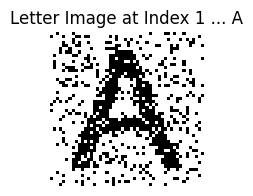

  Predicted: B, Actual: A
  Output: [-0.97  0.98 -1.   -1.   -0.98 -0.6  -0.89 -1.   -1.   -0.98 -1.   -0.99
 -1.   -1.   -1.   -0.87 -1.   -1.   -1.   -1.   -0.96 -1.   -1.   -1.
 -1.   -1.  ]
  Probabilities: [0.01 0.72 0.   0.   0.01 0.14 0.04 0.   0.   0.01 0.   0.   0.   0.
 0.   0.05 0.   0.   0.   0.   0.01 0.   0.   0.   0.   0.  ]


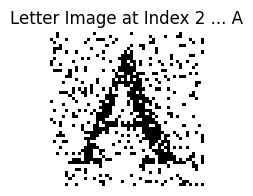

  Predicted: X, Actual: A
  Output: [-0.27 -1.   -1.   -1.   -1.   -0.75 -0.95 -0.99 -1.   -1.   -0.79 -1.
 -0.98 -0.87 -1.   -0.99 -1.   -0.89 -0.96 -1.   -1.   -1.   -1.    0.29
 -1.   -1.  ]
  Probabilities: [0.26 0.   0.   0.   0.   0.09 0.02 0.   0.   0.   0.07 0.   0.01 0.05
 0.   0.   0.   0.04 0.01 0.   0.   0.   0.   0.45 0.   0.  ]


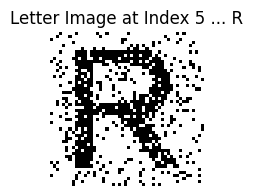

  Predicted: P, Actual: R
  Output: [-0.71 -1.   -1.   -0.99 -1.   -0.98 -1.   -0.79 -1.   -1.   -1.   -1.
 -1.   -1.   -1.   -0.15 -0.99 -0.76 -1.   -0.97 -1.   -1.   -1.   -0.96
 -1.   -1.  ]
  Probabilities: [0.17 0.   0.   0.   0.   0.01 0.   0.12 0.   0.   0.   0.   0.   0.
 0.   0.5  0.01 0.14 0.   0.02 0.   0.   0.   0.03 0.   0.  ]


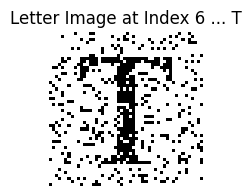

  Predicted: V, Actual: T
  Output: [-1.   -1.   -1.   -0.99 -1.   -0.99 -1.   -1.   -0.97 -1.   -1.   -1.
 -1.   -0.99 -1.   -1.   -1.   -1.   -0.99 -0.66 -1.    0.45 -1.    0.18
 -0.99 -0.94]
  Probabilities: [0.   0.   0.   0.   0.   0.   0.   0.   0.01 0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.11 0.   0.47 0.   0.38 0.   0.02]


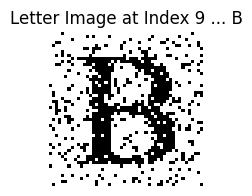

  Predicted: M, Actual: B
  Output: [-0.98  0.74 -0.98 -1.   -0.82 -1.   -1.   -0.7  -1.   -0.99 -0.99 -1.
  0.88 -0.99 -1.   -0.49 -1.   -0.93 -0.95 -1.   -1.   -1.    0.83 -1.
 -1.    0.01]
  Probabilities: [0.   0.23 0.   0.   0.02 0.   0.   0.04 0.   0.   0.   0.   0.25 0.
 0.   0.07 0.   0.01 0.01 0.   0.   0.   0.24 0.   0.   0.13]


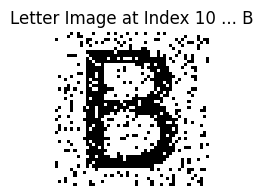

  Predicted: P, Actual: B
  Output: [-0.81 -0.12 -1.   -0.93 -0.72 -1.   -0.96  0.9  -1.   -1.   -1.   -1.
 -1.   -0.99 -1.    0.93 -1.   -0.99 -0.11  0.5  -1.   -1.   -0.26 -1.
 -0.8  -1.  ]
  Probabilities: [0.02 0.1  0.   0.01 0.03 0.   0.   0.22 0.   0.   0.   0.   0.   0.
 0.   0.22 0.   0.   0.1  0.17 0.   0.   0.09 0.   0.02 0.  ]


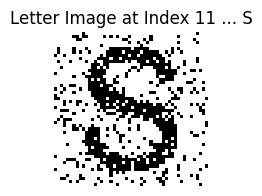

  Predicted: E, Actual: S
  Output: [-1.   -0.99 -1.   -1.    0.97 -1.   -0.97 -0.84 -1.   -0.97 -1.   -1.
 -1.   -0.4  -0.87 -1.   -1.   -0.43 -0.33 -0.59 -1.   -1.   -0.93 -1.
 -0.97 -1.  ]
  Probabilities: [0.   0.   0.   0.   0.42 0.   0.01 0.04 0.   0.01 0.   0.   0.   0.13
 0.03 0.   0.   0.12 0.14 0.09 0.   0.   0.02 0.   0.01 0.  ]


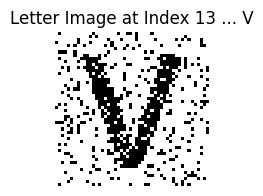

  Predicted: L, Actual: V
  Output: [-1.   -1.   -0.99 -1.   -1.   -0.99 -0.88 -1.   -1.   -1.   -0.57 -0.54
 -1.   -1.   -0.95 -1.   -1.   -0.78 -1.   -1.   -1.   -0.73 -1.   -1.
 -0.89 -1.  ]
  Probabilities: [0.   0.   0.01 0.   0.   0.01 0.07 0.   0.   0.   0.25 0.27 0.   0.
 0.03 0.   0.   0.13 0.   0.   0.   0.16 0.   0.   0.07 0.  ]


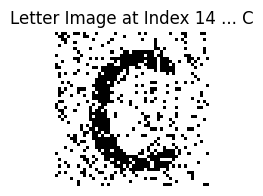

  Predicted: Y, Actual: C
  Output: [-1.   -1.   -0.98 -0.99 -0.99 -0.05 -0.63 -1.   -1.   -1.   -1.   -1.
 -1.   -1.   -1.   -0.99 -1.   -1.   -1.   -1.   -1.   -0.73 -1.   -1.
  0.05 -0.99]
  Probabilities: [0.   0.   0.01 0.   0.   0.35 0.14 0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.1  0.   0.   0.39 0.  ]


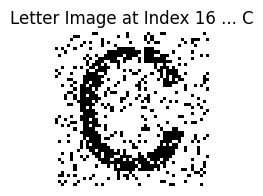

  Predicted: G, Actual: C
  Output: [-1.   -0.92  0.8  -0.83 -0.43 -1.    0.85 -1.   -1.   -0.99 -1.   -1.
 -1.   -1.   -0.89 -0.98 -1.   -0.99 -1.   -1.    0.05 -0.56 -0.94 -0.99
 -0.98 -0.99]
  Probabilities: [0.   0.01 0.29 0.03 0.09 0.   0.3  0.   0.   0.   0.   0.   0.   0.
 0.02 0.   0.   0.   0.   0.   0.17 0.07 0.01 0.   0.   0.  ]


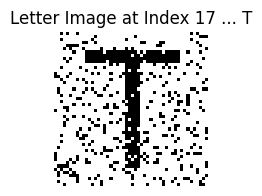

  Predicted: S, Actual: T
  Output: [ 0.61 -1.    0.79 -1.   -1.   -1.   -1.   -0.93 -0.98 -0.95  0.84 -1.
 -1.   -0.99 -0.98 -1.   -1.   -1.    0.99  0.95 -1.   -0.46 -1.   -1.
 -1.   -1.  ]
  Probabilities: [0.16 0.   0.18 0.   0.   0.   0.   0.01 0.   0.01 0.19 0.   0.   0.
 0.   0.   0.   0.   0.2  0.2  0.   0.05 0.   0.   0.   0.  ]


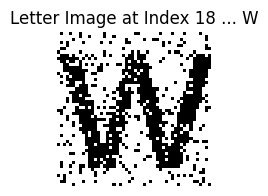

  Predicted: L, Actual: W
  Output: [-1.   -1.   -1.   -0.95 -0.97 -1.   -1.   -1.   -0.99 -1.   -0.11  0.99
 -0.98 -1.   -1.   -1.    0.44 -1.   -0.98 -1.   -1.   -0.97  0.98 -1.
 -1.   -1.  ]
  Probabilities: [0.   0.   0.   0.01 0.   0.   0.   0.   0.   0.   0.14 0.31 0.   0.
 0.   0.   0.22 0.   0.   0.   0.   0.   0.31 0.   0.   0.  ]


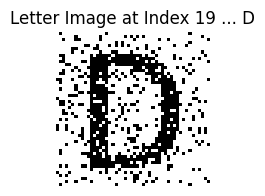

  Predicted: B, Actual: D
  Output: [-1.    0.95 -1.    0.86 -1.   -0.97 -0.27 -1.   -0.48 -0.96 -0.98 -1.
 -0.05 -1.   -1.   -1.   -0.88 -1.   -1.   -1.    0.55 -0.99 -1.   -1.
 -1.   -1.  ]
  Probabilities: [0.   0.25 0.   0.24 0.   0.   0.09 0.   0.07 0.01 0.   0.   0.12 0.
 0.   0.   0.01 0.   0.   0.   0.2  0.   0.   0.   0.   0.  ]


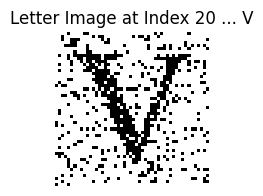

  Predicted: U, Actual: V
  Output: [-0.98 -1.   -0.39 -0.97 -1.   -0.47 -1.   -1.   -1.   -1.   -1.   -1.
 -0.95 -0.98 -1.   -1.   -1.   -1.   -1.   -1.    1.    0.31 -0.99 -0.46
 -1.   -1.  ]
  Probabilities: [0.   0.   0.12 0.01 0.   0.1  0.   0.   0.   0.   0.   0.   0.01 0.
 0.   0.   0.   0.   0.   0.   0.39 0.26 0.   0.11 0.   0.  ]


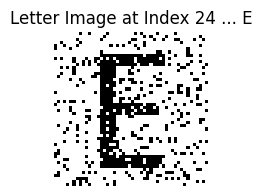

  Predicted: L, Actual: E
  Output: [-1.   -1.   -0.88 -0.95 -1.    0.23 -1.   -1.   -1.   -0.93 -1.    0.67
 -1.   -1.   -1.   -0.88 -0.96 -1.   -0.27 -1.   -0.91 -1.   -1.   -1.
 -0.89 -0.99]
  Probabilities: [0.   0.   0.03 0.01 0.   0.29 0.   0.   0.   0.02 0.   0.39 0.   0.
 0.   0.03 0.01 0.   0.17 0.   0.02 0.   0.   0.   0.03 0.  ]


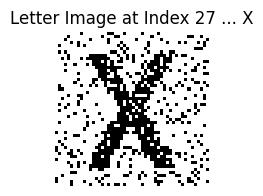

  Predicted: Z, Actual: X
  Output: [-1.   -1.   -0.72 -1.   -1.   -0.52 -1.   -1.   -1.   -1.   -1.    0.66
 -0.99 -0.78 -1.   -1.   -1.   -1.   -1.   -1.   -0.99 -0.99 -1.   -0.7
 -0.12  0.86]
  Probabilities: [0.   0.   0.05 0.   0.   0.08 0.   0.   0.   0.   0.   0.29 0.   0.04
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.05 0.15 0.32]


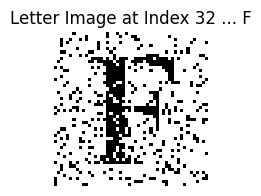

  Predicted: Z, Actual: F
  Output: [-0.99 -0.79 -1.   -1.    0.08 -0.87 -1.   -1.   -1.    0.47 -1.   -0.9
 -1.   -1.   -1.   -1.   -1.   -1.   -0.99 -0.89 -1.   -0.56 -1.   -1.
 -1.    0.67]
  Probabilities: [0.   0.04 0.   0.   0.21 0.03 0.   0.   0.   0.28 0.   0.02 0.   0.
 0.   0.   0.   0.   0.   0.02 0.   0.08 0.   0.   0.   0.32]


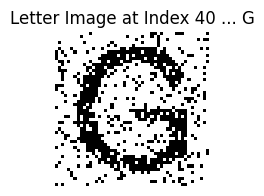

  Predicted: S, Actual: G
  Output: [-1.   -1.   -1.   -1.   -0.99 -0.92 -0.95 -0.99 -1.   -0.02 -1.   -1.
 -0.53 -0.99 -0.99 -0.81 -1.   -0.93  0.57 -1.   -1.   -1.   -1.   -0.99
 -1.   -1.  ]
  Probabilities: [0.   0.   0.   0.   0.   0.02 0.01 0.   0.   0.28 0.   0.   0.14 0.
 0.   0.05 0.   0.02 0.45 0.   0.   0.   0.   0.   0.   0.  ]


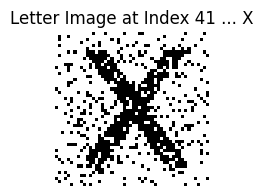

  Predicted: N, Actual: X
  Output: [-1.   -0.99 -1.   -1.   -1.   -1.   -1.    0.18 -1.   -0.98 -1.   -1.
 -1.    0.58 -1.   -0.61 -1.   -1.   -1.   -0.98 -1.   -0.91 -0.81 -0.05
 -1.   -1.  ]
  Probabilities: [0.   0.   0.   0.   0.   0.   0.   0.26 0.   0.01 0.   0.   0.   0.36
 0.   0.09 0.   0.   0.   0.01 0.   0.02 0.04 0.21 0.   0.  ]


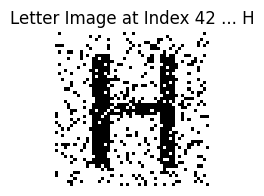

  Predicted: G, Actual: H
  Output: [-1.   -0.99 -1.   -1.   -0.41 -0.33  0.91 -0.24 -1.   -1.   -0.99 -1.
 -1.   -0.35 -1.   -0.76 -1.   -1.   -1.   -1.   -0.91 -1.   -1.   -0.98
 -1.   -0.98]
  Probabilities: [0.   0.   0.   0.   0.12 0.13 0.39 0.15 0.   0.   0.   0.   0.   0.13
 0.   0.05 0.   0.   0.   0.   0.02 0.   0.   0.   0.   0.  ]


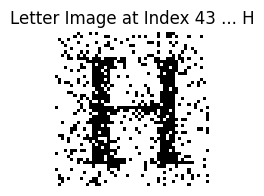

  Predicted: E, Actual: H
  Output: [-0.8  -0.34 -0.97 -0.97  0.45 -0.13 -0.99  0.43 -1.   -1.   -1.   -1.
 -1.   -0.99 -1.   -1.   -1.   -1.   -1.   -1.   -0.95 -0.99 -1.   -1.
 -1.   -1.  ]
  Probabilities: [0.04 0.14 0.01 0.01 0.31 0.18 0.   0.3  0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.01 0.   0.   0.   0.   0.  ]


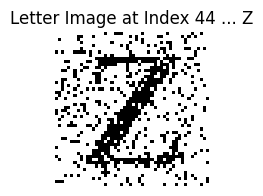

  Predicted: E, Actual: Z
  Output: [-1.   -0.33 -0.99 -0.98  0.99 -1.   -1.   -0.86 -1.   -1.   -1.   -0.99
 -0.98 -1.   -1.   -1.   -0.9  -1.   -1.   -1.   -1.   -0.99 -0.62 -1.
 -1.   -0.99]
  Probabilities: [0.   0.2  0.   0.01 0.59 0.   0.   0.04 0.   0.   0.   0.   0.01 0.
 0.   0.   0.03 0.   0.   0.   0.   0.   0.11 0.   0.   0.  ]


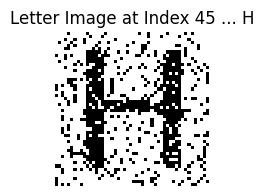

  Predicted: N, Actual: H
  Output: [ 0.21 -1.   -1.   -0.16 -1.   -1.   -1.   -0.9  -1.   -1.   -1.   -1.
 -1.    0.84 -1.   -1.   -0.96 -1.   -1.   -0.61  0.32 -1.   -1.   -1.
 -1.   -1.  ]
  Probabilities: [0.21 0.   0.   0.15 0.   0.   0.   0.02 0.   0.   0.   0.   0.   0.32
 0.   0.   0.01 0.   0.   0.07 0.23 0.   0.   0.   0.   0.  ]


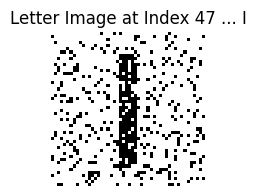

  Predicted: L, Actual: I
  Output: [-1.   -1.   -0.74 -1.   -1.   -1.   -1.   -1.    0.58 -0.96 -1.    0.92
 -1.   -1.   -1.   -1.   -0.54 -1.   -1.   -1.   -0.96 -0.99 -1.   -0.99
 -0.85 -1.  ]
  Probabilities: [0.   0.   0.06 0.   0.   0.   0.   0.   0.35 0.01 0.   0.43 0.   0.
 0.   0.   0.1  0.   0.   0.   0.01 0.   0.   0.   0.03 0.  ]


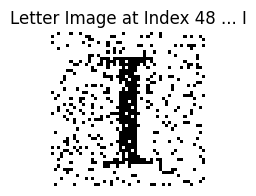

  Predicted: T, Actual: I
  Output: [ 0.7  -1.   -0.87 -1.   -0.42 -1.   -0.98 -1.    0.96 -1.    0.87 -0.4
 -1.   -1.   -1.   -1.   -0.96 -1.   -1.    0.99 -1.   -1.   -1.   -1.
 -1.   -1.  ]
  Probabilities: [0.19 0.   0.01 0.   0.07 0.   0.   0.   0.22 0.   0.21 0.07 0.   0.
 0.   0.   0.   0.   0.   0.22 0.   0.   0.   0.   0.   0.  ]


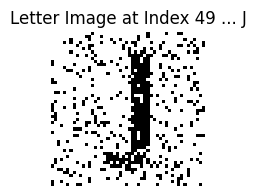

  Predicted: I, Actual: J
  Output: [-0.81 -1.   -0.8  -1.   -1.   -0.99 -1.   -1.    0.99 -0.9  -1.   -1.
 -1.   -1.   -1.   -1.   -0.72 -1.   -0.96 -1.   -1.   -1.   -1.   -1.
 -1.   -1.  ]
  Probabilities: [0.07 0.   0.07 0.   0.   0.   0.   0.   0.7  0.03 0.   0.   0.   0.
 0.   0.   0.1  0.   0.02 0.   0.   0.   0.   0.   0.   0.  ]


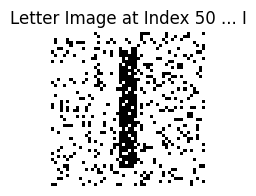

  Predicted: C, Actual: I
  Output: [ 0.74 -0.99  0.96 -1.   -0.96 -0.4  -1.   -1.    0.56 -1.   -1.   -0.99
 -1.   -0.99 -1.   -1.   -0.68 -1.   -0.09 -0.98 -0.96 -0.99 -0.99 -0.98
 -0.97 -0.99]
  Probabilities: [0.24 0.   0.27 0.   0.01 0.08 0.   0.   0.21 0.   0.   0.   0.   0.
 0.   0.   0.04 0.   0.12 0.   0.01 0.   0.   0.   0.   0.  ]


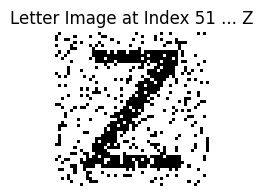

  Predicted: R, Actual: Z
  Output: [-0.99 -1.   -1.   -0.96 -0.82 -1.   -1.   -1.   -1.   -0.69 -1.   -0.26
 -1.   -1.   -1.    0.99 -1.    1.   -1.   -0.99 -1.   -0.58 -1.   -0.99
 -1.   -0.4 ]
  Probabilities: [0.   0.   0.   0.01 0.03 0.   0.   0.   0.   0.05 0.   0.12 0.   0.
 0.   0.31 0.   0.32 0.   0.   0.   0.07 0.   0.   0.   0.1 ]


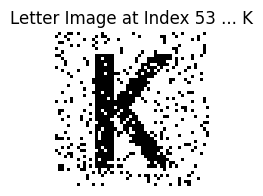

  Predicted: N, Actual: K
  Output: [-1.   -0.99 -1.   -0.9  -1.   -0.94 -1.   -1.   -0.99 -0.94 -0.8  -0.99
 -1.   -0.06 -1.   -1.   -0.97 -1.   -1.   -1.   -1.   -1.   -0.99 -1.
 -1.   -0.99]
  Probabilities: [0.   0.01 0.   0.07 0.   0.04 0.   0.   0.01 0.04 0.14 0.01 0.   0.66
 0.   0.   0.02 0.   0.   0.   0.   0.   0.   0.   0.   0.01]


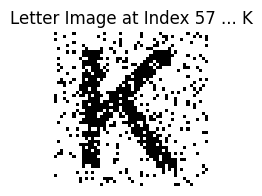

  Predicted: R, Actual: K
  Output: [-1.   -1.   -1.   -1.   -1.   -1.   -0.98 -0.98 -0.99 -0.99  0.39 -1.
 -1.   -0.99 -1.   -1.   -1.    0.97 -0.99 -1.   -1.   -1.   -1.   -0.01
 -1.   -1.  ]
  Probabilities: [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.31 0.   0.   0.
 0.   0.   0.   0.44 0.   0.   0.   0.   0.   0.22 0.   0.  ]


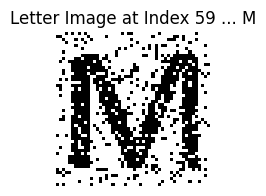

  Predicted: J, Actual: M
  Output: [-0.85  0.27 -1.   -1.   -1.   -0.94 -0.99 -1.   -1.    1.   -0.92 -1.
  0.36 -1.   -1.   -1.   -1.   -0.46 -0.23  0.61  0.78 -0.95 -0.67 -1.
  0.68 -0.99]
  Probabilities: [0.01 0.11 0.   0.   0.   0.   0.   0.   0.   0.17 0.01 0.   0.12 0.
 0.   0.   0.   0.05 0.07 0.14 0.15 0.   0.03 0.   0.14 0.  ]


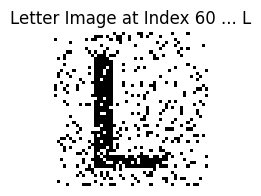

  Predicted: G, Actual: L
  Output: [-1.   -0.89 -0.99 -0.99 -1.   -1.    0.75 -0.99 -1.   -0.99 -1.   -1.
 -1.   -0.89 -1.   -1.   -1.   -1.   -1.   -1.   -1.   -1.   -1.   -1.
 -1.   -1.  ]
  Probabilities: [0.   0.05 0.01 0.   0.   0.   0.87 0.   0.   0.   0.   0.   0.   0.05
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]


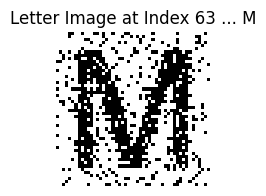

  Predicted: W, Actual: M
  Output: [-1.   -1.   -1.   -1.   -1.   -1.   -1.   -0.97 -1.   -1.   -1.   -0.68
  0.98 -1.   -1.   -0.99 -1.   -1.   -1.   -0.66 -1.   -1.    1.   -0.99
 -0.98 -1.  ]
  Probabilities: [0.   0.   0.   0.   0.   0.   0.   0.01 0.   0.   0.   0.07 0.42 0.
 0.   0.   0.   0.   0.   0.07 0.   0.   0.42 0.   0.   0.  ]


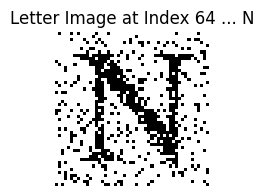

  Predicted: H, Actual: N
  Output: [-1.   -1.   -0.75 -0.99 -1.   -1.   -0.96  1.   -1.   -1.   -1.   -0.93
 -1.    0.38 -0.98 -1.   -1.   -0.99 -1.   -1.   -0.89 -1.   -0.57 -0.61
 -1.   -1.  ]
  Probabilities: [0.   0.   0.05 0.   0.   0.   0.01 0.42 0.   0.   0.   0.02 0.   0.29
 0.01 0.   0.   0.   0.   0.   0.02 0.   0.09 0.08 0.   0.  ]


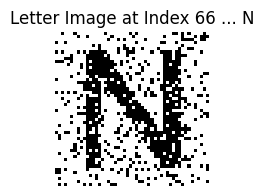

  Predicted: F, Actual: N
  Output: [-1.   -1.   -1.   -1.   -1.    0.08 -1.   -1.   -1.   -1.   -0.97 -0.99
 -1.   -0.32 -1.   -0.95 -1.   -0.37 -0.18 -1.   -0.99 -1.   -1.   -1.
 -0.97 -1.  ]
  Probabilities: [0.   0.   0.   0.   0.   0.32 0.   0.   0.   0.   0.01 0.   0.   0.2
 0.   0.01 0.   0.19 0.24 0.   0.   0.   0.   0.   0.01 0.  ]


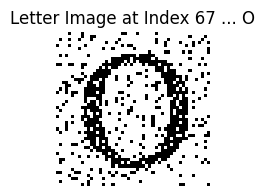

  Predicted: Z, Actual: O
  Output: [-1.   -0.99 -0.99 -0.91 -1.   -1.   -1.   -1.   -1.   -0.99 -1.   -0.83
 -0.99 -1.   -0.83 -0.99 -1.   -1.   -1.   -1.   -1.   -1.   -0.99 -1.
 -1.    0.02]
  Probabilities: [0.   0.01 0.01 0.06 0.   0.   0.   0.   0.   0.01 0.   0.11 0.   0.
 0.11 0.01 0.   0.   0.   0.   0.   0.   0.01 0.   0.   0.67]


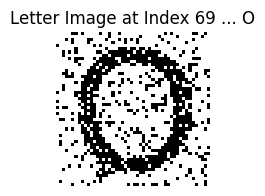

  Predicted: W, Actual: O
  Output: [-1.   -1.   -1.   -0.89 -0.99 -1.    0.93 -0.99 -1.   -0.99 -1.   -1.
 -0.85 -1.   -0.98 -1.   -0.98 -0.99 -1.   -0.95  0.55 -1.    0.98 -1.
 -1.   -1.  ]
  Probabilities: [0.   0.   0.   0.02 0.   0.   0.33 0.   0.   0.   0.   0.   0.03 0.
 0.   0.   0.   0.   0.   0.01 0.26 0.   0.34 0.   0.   0.  ]


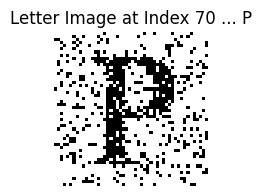

  Predicted: V, Actual: P
  Output: [-1.   -0.93 -1.   -1.   -0.98 -0.97 -1.   -1.   -1.   -1.   -0.73 -0.99
 -0.89 -1.   -0.92  0.99 -1.   -1.   -0.93 -1.   -0.92  1.   -1.   -0.97
 -1.   -0.85]
  Probabilities: [0.   0.01 0.   0.   0.   0.01 0.   0.   0.   0.   0.06 0.   0.02 0.
 0.02 0.41 0.   0.   0.01 0.   0.02 0.41 0.   0.01 0.   0.03]


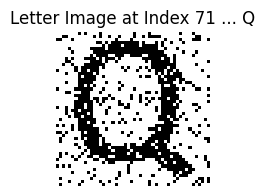

  Predicted: S, Actual: Q
  Output: [ 0.   -0.78 -0.84 -1.   -0.93 -0.99 -0.99 -0.99 -1.   -1.   -1.   -1.
 -1.   -0.98 -0.97 -1.    0.94 -0.99  0.99 -1.   -1.   -1.   -1.   -0.99
 -1.   -1.  ]
  Probabilities: [0.18 0.04 0.03 0.   0.01 0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.35 0.   0.36 0.   0.   0.   0.   0.   0.   0.  ]


In [190]:
outputs = perceptron.forward(inputs_noisy)

# Find misclassified letters
misc = misclassified_indices(true_outputs, outputs)
outputs = perceptron.forward(inputs_noisy)

# Visualize misclassified letters
print("Misclassified Letters:")
for index in misc:
    visualize_letter(inputs_noisy, labels, index)
    predicted_class = np.argmax(outputs[index]) + 1  # Get predicted class index (add 1 to adjust for 1-based indexing)
    print(f"  Predicted: {label_to_letter(predicted_class)}, Actual: {label_to_letter(labels[index])}")
    print(f"  Output: {np.round(outputs[index], 2)}")
    print(f"  Probabilities: {np.round((outputs[index]+1)/np.sum(outputs[index]+1),2)}")